# Table of Contents
<a id="toc"></a>
- [1. Question and goal definition](#1)
- [2. Imports](#2)
- [3. Exploratory Data Analysis](#3)
    - [3.a Overview of Data](#3.a)
    - [3.b Understading the Null Values](#3.b)
    - [3.c Feature Distribution of Continous Features](#3.c)
    - [3.d Feature Distribution of Categorical Features](#3.d)
- [4. Meging](#4)
- [5. Data Cleaning](#5)
    - [5.a Dropping Rows](#5.a)
    - [5.b Droping columns](#5.b)    
- [6. Pre-Processing](#7)
    - [6.a. Binarize Variables](#6.a)
    - [6.b. GPU counts](#6.b)
    - [6.c. Target Creation & Distribution Anlysis](#6.c)
    - [6.d. Feature Engineering](#6.d)
- [7. Modeling](#7) 
- [8. Conclusions](#8)

<!---
TODO:
- replace pie plots with doughnut
- fix user features
- include more models in the analysis i.e. k-NN, Naive Bayes, SVM
- mode the 'biniarizing' section into the preprcessing section
- interesting plots for blog
-->

# Part 1: Question and goal definition <a id="1"></a>

Data centers often require users to predefine time limits to their submitted jobs. As a result, users intentionally set time limits much longer than necessary in order to keep their more time-consuming jobs from being canceled. However, excessive time limits result in many jobs being left idle long after the job has completed its primary function. \
 
Hence, this project's goal is to understand the run times of a given job given the high-level parameters. Additionally, we will demonstrate that AI models can adequately predict job runtimes. This allows for data center to better schedule jobs and efficiently use its resources. The project will involve data cleaning, feature engineering, and developing a model for job runtimes in a cloud-computing scenario.


# Part 2: Imports <a id="2"></a>

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.pyplot import figure


DATA_DIR = "../input/mit-datacenter-challenge-data"

anon_dcgm_df = pd.read_csv(f'{DATA_DIR}/dcgm.csv')
user_df = pd.read_csv(f'{DATA_DIR}/scheduler_data.csv')

# Part 3: EDA of the Raw Data <a id="3"></a>

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    <b><u>Imediate thoughts and observations:</u></b><br>
* <i> There are several columns with <b><u>very</u></b> large variance</i><br>
* <i> The column time_suspended in the user dataset (user_df) is <b><u>constant</u></b> </i><br>
* <i> All of the NaN values are contained in three coluns in the user dataset </i><br>

</div>

# Part 3a.: EDA of the Raw Data <a id="3.a"></a>

In [2]:
anon_dcgm_df.shape, user_df.shape

((96893, 23), (287173, 31))

Text(0.5, 1.0, 'Percentage that are NaN')

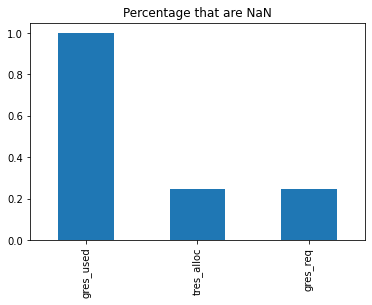

In [3]:
user_df.isna().mean(0).sort_values(ascending=False).iloc[:3] \
    .plot(kind='bar') \
    .set_title('Percentage that are NaN')

In [4]:
anon_dcgm_df.drop(['id_job', 'gpu_id'], axis=1).describe().T.sort_values(by='std' , ascending = False)\
                     .style.background_gradient(cmap='GnBu')\
                     .bar(subset=["max"], color='#BB0000')\
                     .bar(subset=["mean",], color='green')

,count,mean,std,min,25%,50%,75%,max
maxgpumemoryused_bytes,96893.000000,7169811677.755875,10481709508.148819,0.000000,0.000000,2106589184.000000,7762608128.000000,34083962880.000000
energyconsumed_joules,96893.000000,98732.099491,168706.020958,0.000000,1828.000000,10234.000000,133714.000000,868934.000000
totalexecutiontime_sec,96893.000000,22069.848436,99984.702801,0.080000,15.620000,201.040000,5596.680000,2895390.000000
pcierxbandwidth_megabytes_max,96893.000000,1102.159712,738.590877,0.000000,393.000000,1092.000000,1809.000000,2147.000000
pcietxbandwidth_megabytes_max,96893.000000,957.035235,714.644379,0.000000,266.000000,884.000000,1583.000000,2147.000000
pcietxbandwidth_megabytes_min,96893.000000,792.028155,669.515853,0.000000,102.000000,708.000000,1357.000000,2147.000000
pcierxbandwidth_megabytes_min,96893.000000,744.184967,664.887109,0.000000,119.000000,561.000000,1308.000000,2147.000000
pcietxbandwidth_megabytes_avg,96893.000000,874.355733,650.611060,0.000000,248.000000,837.000000,1410.000000,2147.000000
pcierxbandwidth_megabytes_avg,96893.000000,922.292240,609.972447,0.000000,369.000000,948.000000,1393.000000,2147.000000
powerusage_watts_max,96893.000000,115.754833,92.750007,0.000000,27.503000,66.502000,222.825000,337.630000


In [5]:
user_df_categorical_cols = ['id_job', 'id_user', 'gres_used', 'id_array_task', 'id_array_job', 'kill_requid', 'exit_code', 'flags', 'state',
                           'array_task_pending', 'derived_ec', 'cpus_req', 'priority']
user_df.drop(user_df_categorical_cols, axis=1).describe().T.sort_values(by='std' , ascending = False)\
                     .style.background_gradient(cmap='GnBu')\
                     .bar(subset=["max"], color='#BB0000')\
                     .bar(subset=["mean",], color='green')

,count,mean,std,min,25%,50%,75%,max
mem_req,287173.000000,3579146135058055168.000000,4494616743192418816.000000,0.000000,10240.000000,16384.000000,9223372036854784000.000000,9223372036854792192.000000
timelimit,287173.000000,935706978.815801,1772918023.290309,1.000000,240.000000,240.000000,30240.000000,4294967295.000000
time_eligible,287173.000000,12575678.196679,18721932.414521,-1.000000,7821740.000000,8980747.000000,22157253.000000,2715808008.000000
time_start,287173.000000,11967427.251994,9936119.438365,-1.000000,2282590.000000,8692316.000000,21980772.000000,32001780.000000
time_end,287173.000000,14189311.601007,8043992.010570,-1.000000,8077730.000000,8988625.000000,22160270.000000,32001404.000000
time_submit,287173.000000,14199594.298562,8039657.230700,3014.000000,8074972.000000,8989192.000000,22157251.000000,32001779.000000
nodes_alloc,287173.000000,1.476584,12.745401,0.000000,1.000000,1.000000,1.000000,435.000000
array_max_tasks,287173.000000,0.003204,0.151014,0.000000,0.000000,0.000000,0.000000,8.000000
track_steps,287173.000000,0.001598,0.039947,0.000000,0.000000,0.000000,0.000000,1.000000
time_suspended,287173.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000


## 3.b Understading the Null Values <a id="3.b"></a>
## *+ Missingness dependant on unobserved variables*

In [6]:
print('Percentage of the columns that is missing')
user_df.isna().mean(0).sort_values(ascending=False).iloc[:3]

Percentage of the columns that is missing


gres_used     1.000000
tres_alloc    0.245577
gres_req      0.245486
dtype: float64

From the above values, the columns that contain the missing values are 'gres_used', 'tres_alloc', and 'gres_req'. The first of which, 'gres_used' is completely NaN hence the rest of this section is dedicated to the other two columns.

In [7]:
user_df.gres_req.unique()

array([nan, 'gpu:volta:2', 'gpu:volta:1', 'gpu:volta:870',
       'gpu:volta:800', 'gpu:volta:4', 'gpu:volta:16', 'gpu:volta:8',
       'gpu:volta:64', 'gpu:volta:32', 'gpu:volta:128', 'gpu:volta:256',
       'gpu:volta:768', 'gpu:volta:512', 'gpu:volta:6', 'gpu:volta:856',
       'gpu:volta:864', 'gpu:volta:832', 'gpu:volta:680', 'gpu:volta:640',
       'gpu:volta:600', 'gpu:volta:560', 'gpu:volta:540', 'gpu:volta:520',
       'gpu:volta:830', 'gpu:volta:850', 'gpu:volta:48', 'gpu:volta:12',
       'gpu:volta:24', 'gpu:volta:20', 'gpu:volta:28', 'gpu:2', 'gpu:1',
       'gpu:volta:150', 'gpu:volta:786', 'gpu:volta:700', 'gpu:volta:58',
       'gpu:volta:5', 'gpu:volta:696', 'gpu:volta:3', 'gpu:volta:192',
       'gpu:volta:130', 'gpu:4', 'gpu:volta:252', 'gpu:32',
       'gpu:volta:10', 'gpu:16', 'gpu:8', 'gpu:volta:14', 'gpu:3',
       'gpu:12', 'gpu:64'], dtype=object)

We infer from the non-nan values above that 'gres_req' represents information about GPUs. Hence NaNs here represent instances without a GPU. So we find it reasonable to assume that the 'missingness' of these values is not random, but instead dependant on a non-explicitly defined variable (i.e. the usage of GPU resources). Thus we are in a situation that  Gelman, & Hill (2009) would describe as "*Missingness that depends on unobserved predictors*"  [2]. 

Text(0.5, 1.0, 'Count of 5 Common values in tres_alloc')

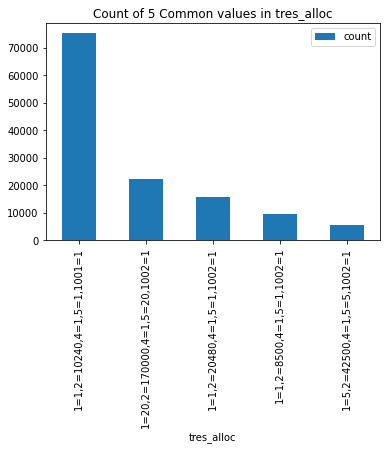

In [8]:
user_df.groupby('tres_alloc')['tres_alloc'].agg(['count']).sort_values('count', ascending=False).iloc[:5]\
    .plot(kind='bar')\
    .set_title('Count of 5 Common values in tres_alloc')

A big takeaway from the plot above is that the most common values in the 'tres_alloc' column are strings of numbers and symbols in a format that is very ambiguous. Without a more comprehensive understanding of this information we cannot draw any inferences in any resulting analysis we could construct using this as a predictor. Thus, for the sake of interpretability, we will exclude this variable.

## Part 3.c Feature Distribution of Continous Features <a id="3.c"></a>

<AxesSubplot:>

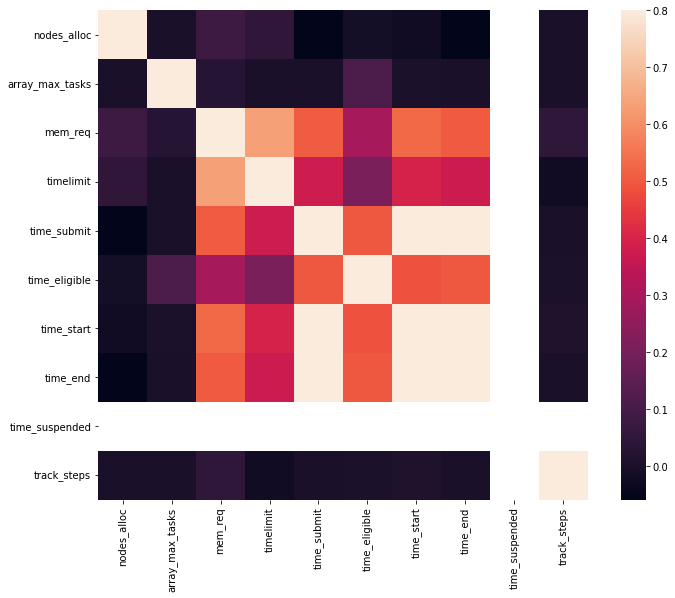

In [9]:
#correlation matrix
corrmat = user_df.drop(user_df_categorical_cols, axis=1).corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

<AxesSubplot:>

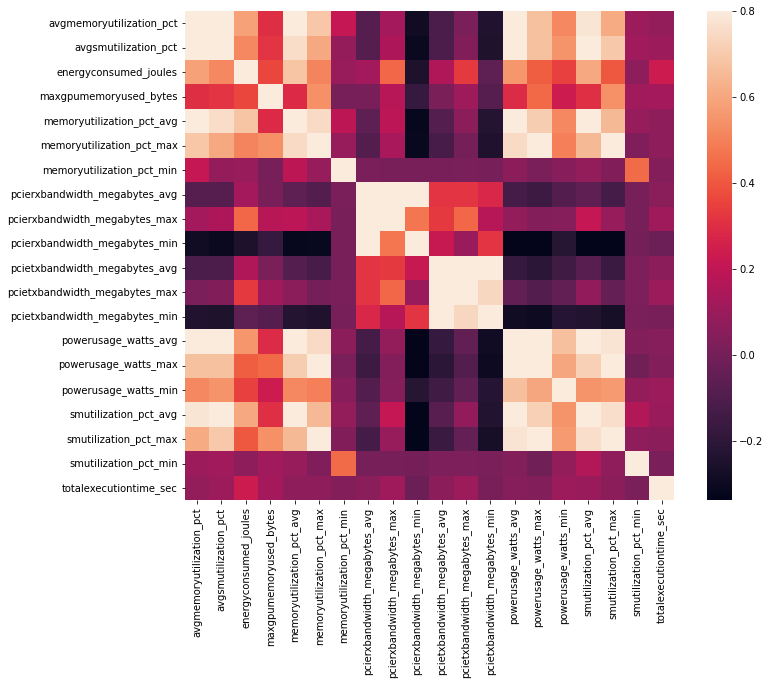

In [10]:
#correlation matrix
corrmat = anon_dcgm_df.drop(['id_job', 'gpu_id'], axis=1).corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

Instead of plotting the densities of every variable, we will instead use the rest of this section to highlight particular aspects of the data.

Based on the following few plots we can see many of the variables are highly skewed. Perhaps non-traditional normalization techniques and/or non-linear variable transformorms could be useful.

In [11]:
print('Skews of "anon_dcgm_df"')

skew_df = anon_dcgm_df.drop(['gpu_id', 'id_job', 'Node'], axis=1).skew().sort_values( ascending = False)
skew_df = skew_df.iloc[:4]
skew_df

Skews of "anon_dcgm_df"


memoryutilization_pct_min    29.003981
smutilization_pct_min        15.344765
totalexecutiontime_sec       12.931740
energyconsumed_joules         2.276109
dtype: float64

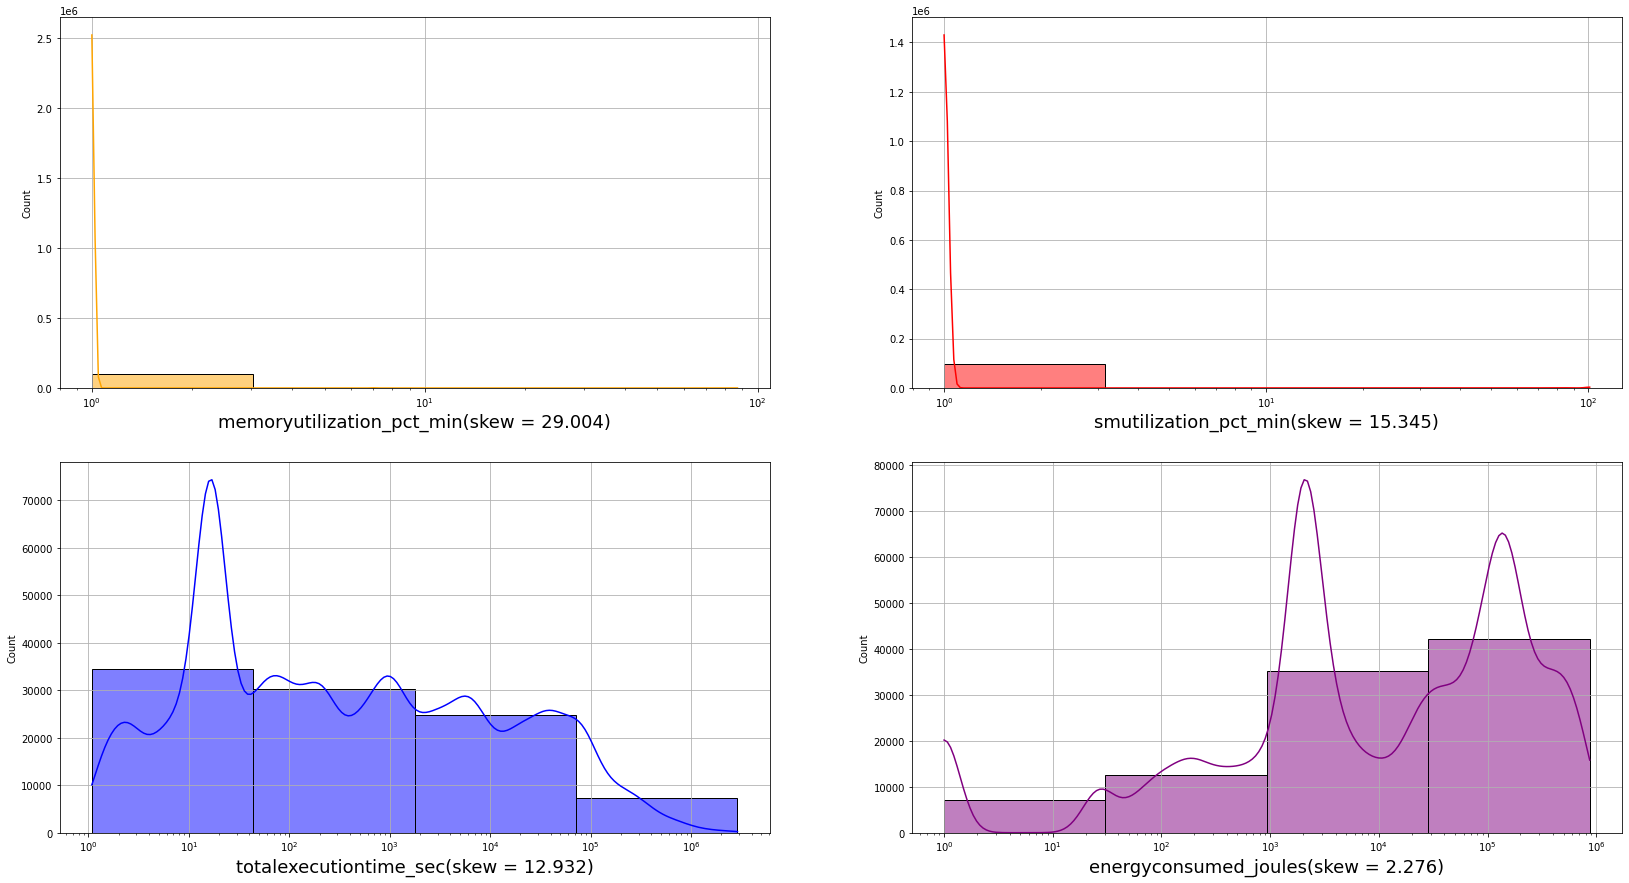

In [12]:
locs = [(2,2,1), (2,2,2), (2,2,3), (2,2,4)]
colours = ['orange', 'red', 'blue', 'purple']
titles = skew_df.index.values
skews = skew_df.values

plt.figure(figsize=(28,15))
for (l, c, t, s) in zip(locs, colours, titles, skews):
    
    plt.subplot(*l)
    sns.histplot(anon_dcgm_df[t] + 1, color=c, kde=True, bins=4, log_scale=True)
    plt.xlabel(t + f'(skew = {round(s, 3)})',fontsize=18)
    plt.grid()


In [13]:
print('Skews of "user_df"')

skew_df = user_df.drop(user_df_categorical_cols, axis=1).skew().sort_values( ascending = False)
skew_df = skew_df.iloc[:4]
skew_df

Skews of "user_df"


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  This is separate from the ipykernel package so we can avoid doing imports until


time_eligible      104.874536
array_max_tasks     50.747577
nodes_alloc         25.435321
track_steps         24.953103
dtype: float64

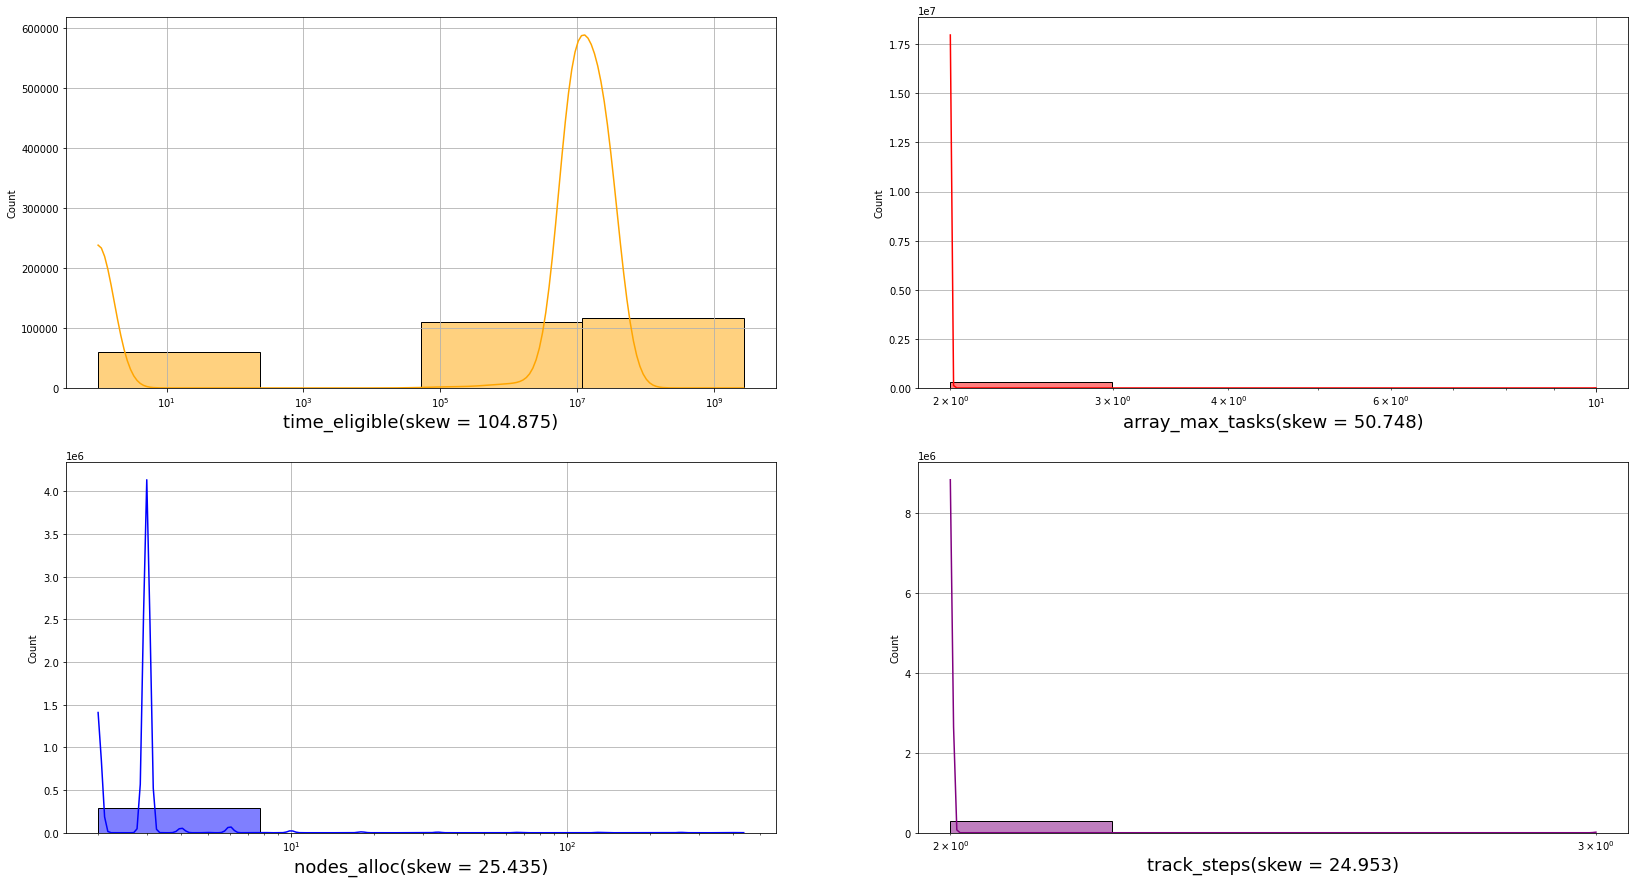

In [14]:
locs = [(2,2,1), (2,2,2), (2,2,3), (2,2,4)]
colours = ['orange', 'red', 'blue', 'purple']
titles = skew_df.index.values
skews = skew_df.values

plt.figure(figsize=(28,15))
for (l, c, t, s) in zip(locs, colours, titles, skews):
    
    plt.subplot(*l)
    sns.histplot(user_df[t] + 2, color=c, kde=True, bins=4, log_scale=True)
    plt.xlabel(t + f'(skew = {round(s, 3)})',fontsize=18)
    plt.grid()


Note in the histograms above we applied a log transformation however some of the columns are still highly skewed after the transformation.
The following feature engineering section will replace some of the highly skewed variables with an indicator variable. These new binary variables are 1 only if the original variable is in its high-density region, zero otherwise.


# 3.d Feature Distribution of Categorical Features <a id="3.d"></a>

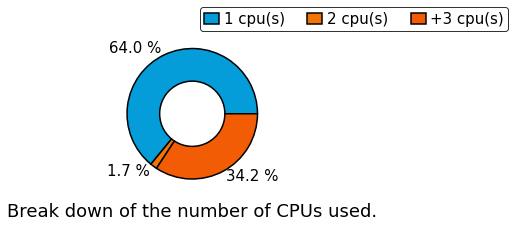

In [15]:
def plot_donut(values, labels, title):
    sizes=values
    sizes=sizes/sum(sizes)*100
    sizes=np.round(sizes,1)

    fig, ax = plt.subplots(1,1,figsize=(6.2, 3), subplot_kw=dict(aspect="equal"))
    plt.rcParams['font.size'] = 15
    colors=["#049DD9","#F27405","#F25C05","#233D8C", "#203573"]
    wedgeprops={"edgecolor":"black",'linewidth': 1.5, 'linestyle': '-', 'antialiased': True,"width":0.5}
    ax.pie(sizes, colors=colors, wedgeprops=wedgeprops, startangle=0, labels=[str(b)+" %" for b in sizes])
    # fig.subplots_adjust(left=0.085, right=0.995, top=0.955, bottom=0.25, wspace=0.42)
    fig.subplots_adjust(wspace=1)
    ax.set_xlabel(title,fontsize=18)
    ax.legend(labels ,ncol=4, loc='upper left', bbox_to_anchor=(0.5, 1.2),
               fontsize=15,edgecolor='black',borderpad=0.3,handletextpad=0.3,handlelength=1,columnspacing=1.5)
    plt.savefig('cpu.png', transparent=True)
    plt.show()
    
    
k = 2
count_df = user_df.groupby('cpus_req')['nodes_alloc'].agg(['count'])
top_df = count_df[:k].copy()
new_row = pd.DataFrame(data = {
    'cpus_req' : [f'+{k+1}'],
    'count' : [count_df['count'][k:].sum()]
}).set_index('cpus_req')
count_df = pd.concat([top_df, new_row])
values = count_df.values[:, 0]
labels = count_df.index.astype(str) + " cpu(s)"
title = 'Break down of the number of CPUs used.'
    

plot_donut(values, labels, title)

In [16]:
user_df.cpus_req.mean()

10.976157229265983

Users request 11 cpus on average and but they only request for one cpu most often. The second most popular number of cpus requested is 2, but only accounts for 1.7% of the total runtimes.

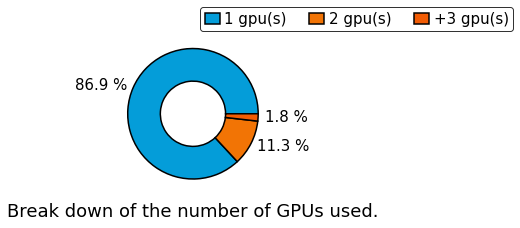

In [17]:
# first group by the unique runtimes (ie. id_job) to count the number of gpus
# we will use this a feature for modeling later on
count_df = anon_dcgm_df.groupby('id_job')['gpu_id'].agg(['count'])\
.rename({'count': 'gpu_count'}, axis=1)\
.reset_index() 

count_df = count_df.groupby('gpu_count').agg(['count']).id_job

k = 2
top_df = count_df[:k].copy()
new_row = pd.DataFrame(data = {
    'id_job' : ['+3'],
    'count' : [count_df['count'][k:].sum()]
}).set_index('id_job')
count_df = pd.concat([top_df, new_row])

values = count_df.values[:, 0]
labels = count_df.index.astype(str) + " gpu(s)"
title = 'Break down of the number of GPUs used.'

plot_donut(values, labels, title)

In [18]:
count_df['percentage'] = count_df['count'] / count_df['count'].sum()
count_df

,count,percentage
1,65021,0.868696
2,8472,0.113188
+3,1356,0.018116


The vast majority of runtimes use a single GPU. This makes sense since even jobs that require multiple GPUs are likely to necessitate many smaller single GPU runtimes. Where these smaller jobs are to test and benchmark their framework in preparation for the high resource runtime.  

# Part 4: Merging <a id="4"></a>

Here we will inner-merge the two data frames on the unique runtime identifier: id_job. Note that by inner-merging we thereby remove the CPU-only runtimes.

In [19]:
anon_dcgm_df.columns

Index(['Node', 'avgmemoryutilization_pct', 'avgsmutilization_pct',
       'energyconsumed_joules', 'gpu_id', 'maxgpumemoryused_bytes',
       'memoryutilization_pct_avg', 'memoryutilization_pct_max',
       'memoryutilization_pct_min', 'pcierxbandwidth_megabytes_avg',
       'pcierxbandwidth_megabytes_max', 'pcierxbandwidth_megabytes_min',
       'pcietxbandwidth_megabytes_avg', 'pcietxbandwidth_megabytes_max',
       'pcietxbandwidth_megabytes_min', 'powerusage_watts_avg',
       'powerusage_watts_max', 'powerusage_watts_min', 'smutilization_pct_avg',
       'smutilization_pct_max', 'smutilization_pct_min',
       'totalexecutiontime_sec', 'id_job'],
      dtype='object')

In [20]:
user_df.columns

Index(['id_array_job', 'id_array_task', 'id_user', 'kill_requid',
       'nodes_alloc', 'nodelist', 'cpus_req', 'derived_ec', 'exit_code',
       'gres_req', 'gres_alloc', 'gres_used', 'array_max_tasks',
       'array_task_pending', 'constraints', 'flags', 'mem_req', 'partition',
       'priority', 'state', 'timelimit', 'time_submit', 'time_eligible',
       'time_start', 'time_end', 'time_suspended', 'track_steps', 'tres_alloc',
       'tres_req', 'job_type', 'id_job'],
      dtype='object')

In [21]:
anon_dcgm_df = anon_dcgm_df.set_index('id_job')

In [22]:
# the original authors use this block to drop duplicates, without a better understanding one cannot explain it here
# reference: https://github.com/boringlee24/HPCA22_SuperCloud/blob/main/notebook.ipynb


tmp_df=user_df[user_df['id_job'].duplicated(keep=False)][['id_job', 'derived_ec', 'state']] #may need to rewrite for 2021-IAP. it doesnt have these columns
idx_to_drop=tmp_df.index[tmp_df['state']!=3]
user_df_no_dup=user_df.drop(idx_to_drop)
assert (user_df_no_dup.shape[0]==len(user_df_no_dup['id_job'].unique())) #all unique now

user_df = user_df_no_dup.set_index('id_job')

In [23]:
gpu_user_join=anon_dcgm_df.join(user_df,how='inner')
gpu_user_join.shape

(96805, 52)

# Part 5: Data Cleaning <a id="5"></a>

## Part 5.a Dropping Rows <a id="5.a"></a>

Hwew ee remove the constant columns and columns that are given in an obscure or proprietary format. Recall that we are trying to understand the lengths of user runtimes hence we remove rows with undefined start/end times.

In [24]:
gpu_user_join = gpu_user_join[gpu_user_join.time_start != -1]
gpu_user_join = gpu_user_join[gpu_user_join.time_end != -1]
gpu_user_join.shape

(96803, 52)

## 5.b Droping columns <a id="5.b"></a>

We drop the constant variable 'time_suspended' and the uninterpretable variables 'tres_req' and 'flags'.

In [25]:
gpu_user_join = gpu_user_join.drop(['tres_req', 'time_suspended', 'flags'], axis=1)

In [26]:
print(f'Note {(gpu_user_join.array_max_tasks == 0).mean()} of the "array_max_tasks" variable is 0 thus we drop it')
gpu_user_join = gpu_user_join.drop(['array_max_tasks'], axis=1)

Note 0.9991942398479386 of the "array_max_tasks" variable is 0 thus we drop it


Next we drop columns related to resource utilisation. These are computed when the runtime is over, thus we drop them.

In [27]:
                                    
gpu_user_join = gpu_user_join.drop(['memoryutilization_pct_avg', 'memoryutilization_pct_max',
       'memoryutilization_pct_min', 'pcierxbandwidth_megabytes_avg',
       'pcierxbandwidth_megabytes_max', 'pcierxbandwidth_megabytes_min',
       'pcietxbandwidth_megabytes_avg', 'pcietxbandwidth_megabytes_max',
       'pcietxbandwidth_megabytes_min', 'powerusage_watts_avg',
       'powerusage_watts_max', 'powerusage_watts_min', 'smutilization_pct_avg',
       'smutilization_pct_max', 'smutilization_pct_min', 'avgmemoryutilization_pct', 'avgsmutilization_pct',
       'track_steps', 'energyconsumed_joules', # 'energyconsumed_joules',             
        'maxgpumemoryused_bytes','totalexecutiontime_sec', ], axis=1)

# Part 6: Pre-Processing <a id="6"></a>

## 6.a. Binarize Variables<a id="6.a"></a>

To binarize a variable means to convert it into a binary format with values of 0 and 1. This can be useful in several cases. If a variable is categorical and most of its values belong to only one category, binarizing it can help simplify the data. For continuous variables, we can create a binary indicator based on a certain threshold. 

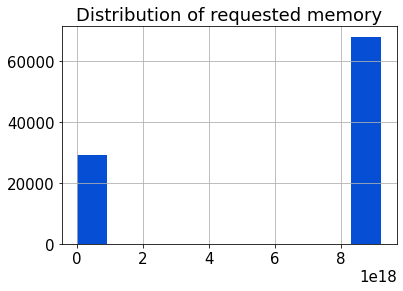

In [28]:
gpu_user_join.mem_req.hist(bins=10, color='#064FD4').set_title('Distribution of requested memory')
cut_off = 9223372036854779557
mem_req = gpu_user_join.mem_req.copy()

gpu_user_join['large_mem_req'] = (gpu_user_join.mem_req.values > cut_off).astype('float32')

As per the plot directly below there seems to be a big group of jobs that request a very large memory and time limit requirement. Perhaps these high resource jobs are from privileged users or perhaps these values are capped by the system later on. Here we replace each value with binary variables which are 1 if the requested memory and time are very large respectively.

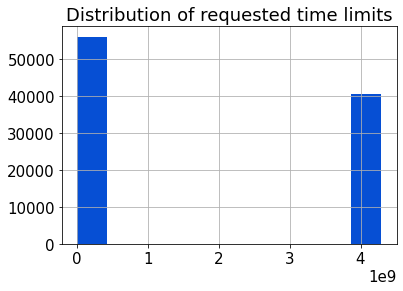

In [29]:
gpu_user_join.timelimit.hist(bins=10, color='#064FD4').set_title('Distribution of requested time limits')
cut_off = 2000000000

gpu_user_join['large_time_req'] = (gpu_user_join.timelimit.values > cut_off).astype('float32')

Similarly these seems to be two distinct groups of the priorities of different jobs. Here we replace it with a binary variable in a similar fashion.

0.19202918

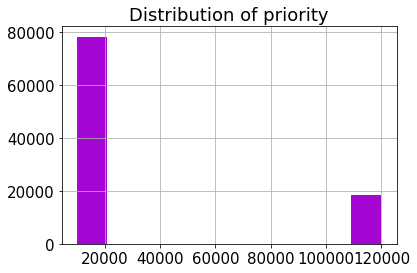

In [30]:
gpu_user_join.priority.hist(bins=10, color='#A406D4').set_title('Distribution of priority')
cut_off = 60000

# thus replace the variable with a indicator which is 1 if the job has a large priority value
gpu_user_join['large_priority'] = (gpu_user_join.priority > cut_off).astype('float32')
gpu_user_join['large_priority'].mean()

The about 50 percent of the id_array_task and the id_array_job variables are a single value, hence we also replace it with an indicator column.

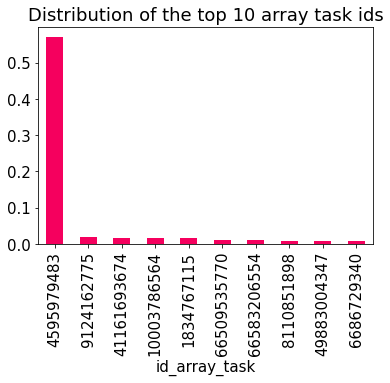

In [31]:
count_df = gpu_user_join.groupby('id_array_task')['id_array_task'].agg(['count'])
count_df['percentage'] = count_df['count'] / count_df['count'].sum()

_=count_df['percentage'].sort_values(ascending=False).iloc[:10].plot.bar(color='#F5005E')\
.set_title('Distribution of the top 10 array task ids')

gpu_user_join['id_array_task=4595979483'] = (gpu_user_join.id_array_task == 4595979483).astype('float32')

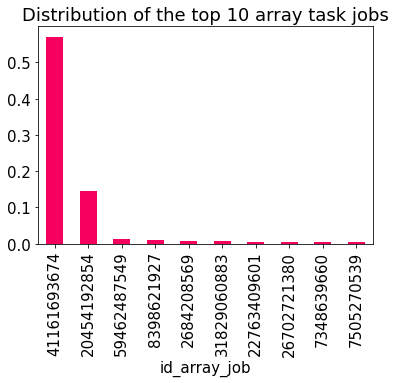

In [32]:
count_df = gpu_user_join.groupby('id_array_job')['id_array_job'].agg(['count'])
count_df['percentage'] = count_df['count'] / count_df['count'].sum()

_=count_df['percentage'].sort_values(ascending=False).iloc[:10].plot.bar(color='#F5005E')\
.set_title('Distribution of the top 10 array task jobs')

gpu_user_join['id_array_job=41161693674'] = (gpu_user_join.id_array_job == 41161693674).astype('float32')

Variables that contain error codes (i.e. exit_code, kill_requid & derived_ec), including time-out errors that terminate a runtime if they run past their defined timelimit, are largely undefined to me. If anyone can help with interpreting these codes that would be appreciated. Without the domain knowledge, I will subsequently drop these columns even though they are likely related to the lengthiness of a runtime.

In [33]:
print(f'note the "array_task_pending" has {len(gpu_user_join.array_task_pending.unique())} unique element, hence we drop it')

note the "array_task_pending" has 1 unique element, hence we drop it


In [34]:
gpu_user_join = gpu_user_join.drop(['priority', 'id_array_task', 'array_task_pending', 'timelimit', 'state', 'id_array_job',
                                   'exit_code', 'derived_ec', 'kill_requid'], axis=1)

## Part 6.b: GPU counts <a id="6.b"></a>

Every entry in the merged data is associated with a single GPU id. Thus if a job requires 64 GPUs the job is represented as 64 rows in the data outlining the power consumption associated with each GPU. Hence in order to study runtimes individually, we need to aggregate the data such that each row represents a runtime. Here we take the mean power consumption entries across every GPU associated with a runtime, assuming they should be identical across a runtime.


In [35]:
gpu_user_join_id_averaged= gpu_user_join.groupby('id_job').mean()
gpu_counts_df = gpu_user_join.groupby('id_job')['gpu_id'].agg(['count'])

In [36]:
gpu_user_join = pd.concat([gpu_user_join_id_averaged, gpu_counts_df], axis=1)

In [37]:
# next we drop the columns associated with a particular GPU
gpu_user_join = gpu_user_join.drop(['gpu_id', 'gres_used', 'nodes_alloc'], axis=1)
gpu_user_join.shape

(74820, 13)

## 6.c. Target Creation & Distribution Anlysis <a id="6.c"></a>

Here the target variable is defined as the difference between the recorded start and end times. This includes the time waiting for the resources to allocate to a user's runtime, which we will show can last for hours.

In [38]:
gpu_user_join['run_time_from_user_df']=gpu_user_join['time_end']-gpu_user_join['time_start']
gpu_user_join['log1p_run_time_from_user_df'] = np.log1p(gpu_user_join['run_time_from_user_df'])

Based on the plots below we replace the target run_time_from_user_df with its log because transformed data better resembles a normal distribution.

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


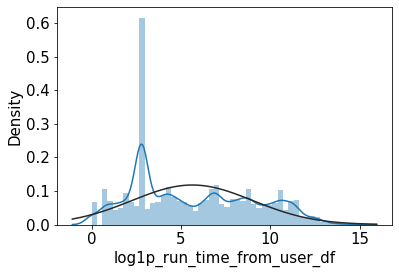

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='run_time_from_user_df', ylabel='Density'>

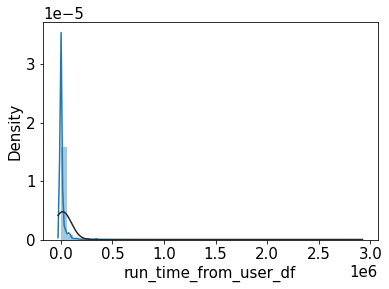

In [39]:
from scipy import stats
from scipy.stats import norm

sns.distplot(gpu_user_join['log1p_run_time_from_user_df'], fit=norm,)
plt.show()
sns.distplot(gpu_user_join['run_time_from_user_df'], fit=norm)

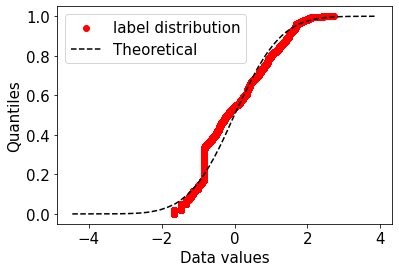

In [40]:
import matplotlib.pyplot as plt

data = gpu_user_join['log1p_run_time_from_user_df'].values
data = (data - data.mean()) / data.std()

# Sort the data and calculate the quantiles
data_sorted = np.sort(data)
quantiles = np.linspace(0, 1, len(data_sorted))

# Generate the Q-Q plot
fig, ax = plt.subplots()
ax.scatter(data_sorted, quantiles, c="red", marker="o", label="label distribution")

# Add a line for the theoretical quantiles of the normal distribution
theoretical_quantiles = np.sort(np.random.normal(0, 1, size=len(data_sorted)))
ax.plot(theoretical_quantiles, quantiles, c="black", linestyle="--", label="Theoretical")

# Add a legend and label the axes
ax.legend()
ax.set_xlabel("Data values")
ax.set_ylabel("Quantiles")

plt.show()

## Part 6.d: Feature engineering <a id="6.d"></a>

In [41]:
gpu_user_join['gpu_per_cpu_count'] = gpu_user_join['count'].astype('float32') / gpu_user_join['cpus_req']
gpu_user_join['cpu_per_gpu_count'] = gpu_user_join['cpus_req'] / gpu_user_join['count'].astype('float32')

In [42]:
gpu_user_join['gpu_per_cpu_count'] = gpu_user_join['gpu_per_cpu_count'].map(np.log1p)
gpu_user_join['cpu_per_gpu_count'] = gpu_user_join['cpu_per_gpu_count'].map(np.log1p)

In [43]:
gpu_user_join['wait_time']=gpu_user_join['time_start']-gpu_user_join['time_submit']

Text(0.5, 1.0, 'Distribution of repeat users.')

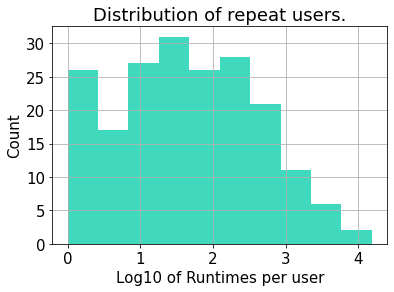

In [44]:
counts_df = gpu_user_join.groupby('id_user')['id_user'].agg(['count'])

axarr=counts_df['count'].map(np.log10).hist(bins=10, color='#41D9BD')
axarr.set_xlabel("Log10 of Runtimes per user")
axarr.set_ylabel("Count")
axarr.set_title('Distribution of repeat users.')


Next we plot these new newly created features against user runtimes and against each other.

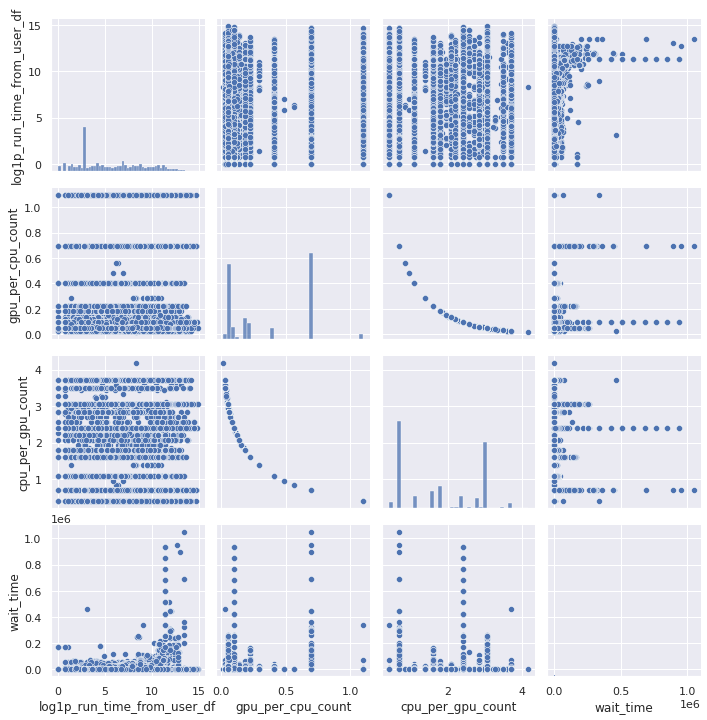

In [45]:
sns.set()
cols = [
    'log1p_run_time_from_user_df', 
    'gpu_per_cpu_count',
    'cpu_per_gpu_count',
    'wait_time'
]
sns.pairplot(gpu_user_join[cols], height=2.5)
plt.show()

In [46]:
# drop all time related columns that are not the target variable
gpu_user_join = gpu_user_join.drop(['run_time_from_user_df', 'time_submit', 'time_eligible', 'time_start', 'time_end'], axis=1)

# 7. Modeling <a id="7"></a>

In this section, our goal is to identify the variables that are the best predictors of the (log) duration of runtimes. To do this, we will use three different modeling techniques: K-nearest neighbors (KNN), support vector machines (SVM), and light gradient boosting machine (LGBM). We evaluate the models using a 10-fold cross-validation.

In [47]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold, train_test_split
from lightgbm import LGBMRegressor


scaler = StandardScaler()
le = LabelEncoder()

In [48]:
target = 'log1p_run_time_from_user_df'
Y = gpu_user_join[target].values

df = gpu_user_join.drop(['log1p_run_time_from_user_df', 'id_user', 'mem_req'], axis=1)

In [49]:
categoricals = ['large_mem_req', 'large_priority',
 'id_array_task=4595979483', 'large_time_req', 'id_array_job=41161693674']


numericals = [x for x in set(df.columns) if (x not in categoricals)]
features = categoricals + numericals
print(f'There are {len(features)} predictors.')

There are 10 predictors.


Next we normalise the vaariables .

In [50]:
df[numericals] = scaler.fit_transform(df[numericals])

for c in categoricals:
    if c in df:
        df[c] = le.fit_transform(df[c])

In [51]:
# seed used for data spliting
random_state = 7777222

Finnaly we define the metrics and then we train the models.

In [52]:
# Metrics


def rmse(y, p):
    return ((y-p)**2).mean() ** .5


def r2(y, p):
    return np.corrcoef(y, p)[0, 1] ** 2

In [53]:
from sklearn.neighbors import KNeighborsRegressor


def score_knn(n_neighbors=5):
    val_rmse = []
    val_r2 = []
    residuals = []

    skf = KFold(n_splits=10, shuffle=True, random_state=random_state)
    for fold, (train_idx, valid_idx) in enumerate(skf.split(df, Y)):

        X_train, X_valid = df.iloc[train_idx], df.iloc[valid_idx]
        y_train , y_valid = Y[train_idx] , Y[valid_idx]

        model = KNeighborsRegressor(n_neighbors=10)
        model.fit(X_train, y_train)

        preds_valid = model.predict(X_valid)
        val_rmse.append(rmse(y_valid, preds_valid))
        val_r2.append(r2(y_valid, preds_valid))
        residuals.append((y_valid, preds_valid))
    
    return np.mean(val_rmse), np.mean(val_r2), np.mean(residuals, axis=0)

val_rmse, val_r2, _ = score_knn(5)
print("Five knn:  Mean RMSE :", round(val_rmse, 4), "Mean R squared :", round(val_r2, 4))

knn_val_rmse, knn_val_r2, residuals = score_knn(10)
print("Ten knn:  Mean RMSE :", round(knn_val_rmse, 4), "Mean R squared :", round(knn_val_r2, 4))

Five knn:  Mean RMSE : 2.5361 Mean R squared : 0.4457
Ten knn:  Mean RMSE : 2.5361 Mean R squared : 0.4457


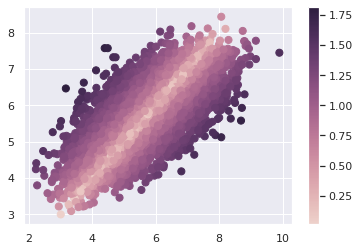

In [54]:
cmap = sns.cubehelix_palette(as_cmap=True)
f, ax = plt.subplots()
points = ax.scatter(
    residuals[0], residuals[1], c=np.abs(residuals[0]-residuals[1]) ** .5, s=50, cmap=cmap
)
f.colorbar(points)
sns.set(rc={'figure.figsize':(11.7,8.27)})
plt.show()

In [55]:

from sklearn.svm import SVR


def score_svm():
    val_rmse = []
    val_r2 = []

    skf = KFold(n_splits=10, shuffle=True, random_state=random_state)
    for fold, (train_idx, valid_idx) in enumerate(skf.split(df, Y)):

        X_train, X_valid = df.iloc[train_idx], df.iloc[valid_idx]
        y_train , y_valid = Y[train_idx] , Y[valid_idx]

        model = SVR(C=1.0, epsilon=0.2)
        model.fit(X_train, y_train)

        preds_valid = model.predict(X_valid)
        val_rmse.append(rmse(y_valid, preds_valid))
        val_r2.append(r2(y_valid, preds_valid))
    
    return np.mean(val_rmse), np.mean(val_r2)


svm_val_rmse, svm_val_r2 = score_svm()
# svm_val_rmse, svm_val_r2 = 2.7895, 0.3291
print("SVM:  Mean RMSE :", round(svm_val_rmse, 4), "Mean R squared :", round(svm_val_r2, 4))

SVM:  Mean RMSE : 2.7895 Mean R squared : 0.3291


In [56]:
lgb_params = dict(boosting_type='gbdt', objective='regression', seed=1234,
                  learning_rate=0.17, n_estimators=100, 
                  metric='rmse', reg_lambda=0.9)


val_rmse = []
val_r2 = []
feature_importances = []
residuals = []


skf = KFold(n_splits=10, shuffle=True, random_state=random_state)
for fold, (train_idx, valid_idx) in enumerate(skf.split(df, Y)):

    X_train, X_valid = df.iloc[train_idx], df.iloc[valid_idx]
    y_train , y_valid = Y[train_idx] , Y[valid_idx]

    model = LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train, categorical_feature=categoricals)

    preds_valid = model.predict(X_valid, categorical_feature=categoricals)
    val_rmse.append(rmse(y_valid, preds_valid))
    val_r2.append(r2(y_valid, preds_valid))
    residuals.append((y_valid, preds_valid))
    
    fim = pd.DataFrame(index=features,
                 data=model.feature_importances_,
                 columns=[f'{fold}_importance'])
    feature_importances.append(fim)


residuals = np.mean(residuals, axis=0)
lgb_val_rmse, lgb_val_r2 = np.mean(val_rmse), np.mean(val_r2)
print("Mean RMSE :", lgb_val_rmse, "Mean R squared :", lgb_val_r2)

/opt/conda/lib/python3.7/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


Mean RMSE : 2.470064341209261 Mean R squared : 0.4679709015523705


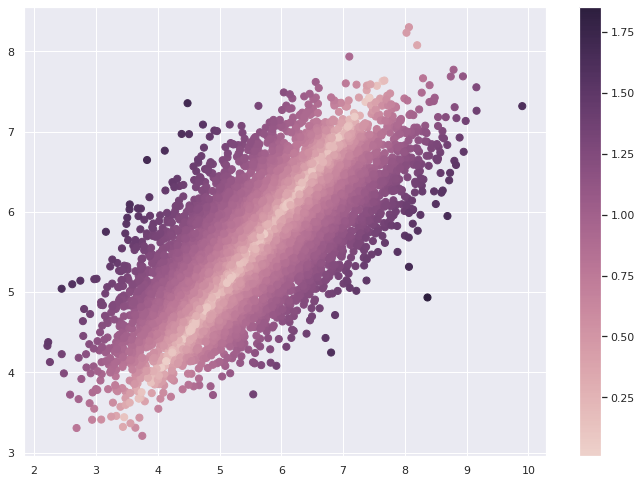

In [57]:
cmap = sns.cubehelix_palette(as_cmap=True)
f, ax = plt.subplots()
points = ax.scatter(
    residuals[0], residuals[1], c=np.abs(residuals[0]-residuals[1]) ** .5, s=50, cmap=cmap
)
f.colorbar(points)
sns.set(rc={'figure.figsize':(11.7,8.27)})
plt.show()

Note that on average every model obtained a very high R-squared, which is interesting. Next, we plot the feature importances.

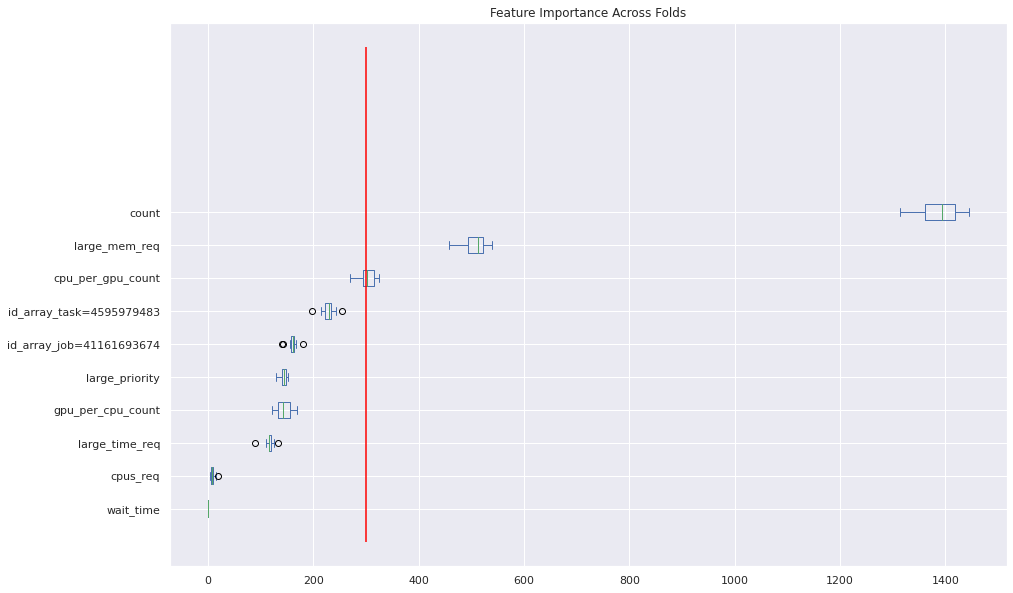

In [58]:
feature_importances_df = pd.concat(feature_importances, axis=1).head(15)
ax = feature_importances_df.sort_values('1_importance').T.plot(kind='box', figsize=(15, 10),
                                       title='Feature Importance Across Folds',
                                                       vert=False)
ax.vlines(feature_importances_df.values.mean(), 0, 15, color='red', linestyle='-')


Note the red line above is the average feature importance across all possible predictors in the data. From the above, the most important variable is the number of gpus requested for a runtime.
Moreover, whether or not large memory resources are requested is also a significant feature when determining the length of a runtime.

In [59]:
def jitter(x, eps=.05):
    return x + np.random.normal(scale=eps)

cpus = gpu_user_join['cpus_req'].map(np.log2).map(jitter)
gpus = gpu_user_join['count'].map(np.log2).map(jitter)
cg = gpu_user_join['cpu_per_gpu_count'].map(jitter)
lmr = gpu_user_join['large_mem_req'].map(jitter)

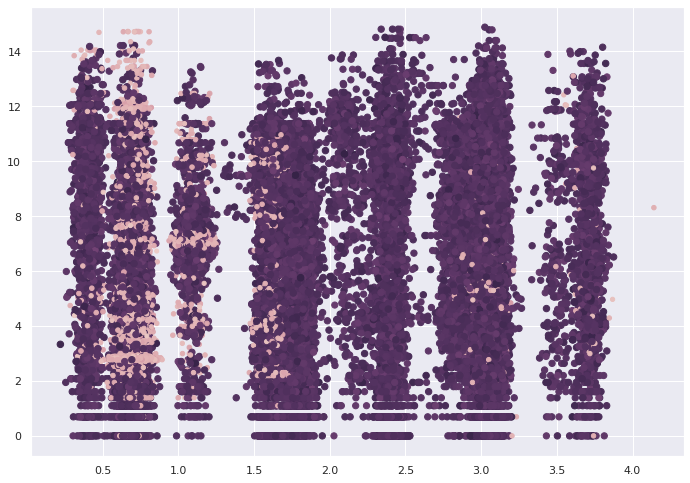

In [60]:
cmap = sns.cubehelix_palette(as_cmap=True)
f, ax = plt.subplots()
points = ax.scatter(
    cg, Y,
    c=lmr,  s=(1+lmr)*20, cmap=cmap
)
sns.set(rc={'figure.figsize':(11.7,8.27)})
plt.show()

However the distribution (of runtime length) over gpus requested seems to be fairly uniform.

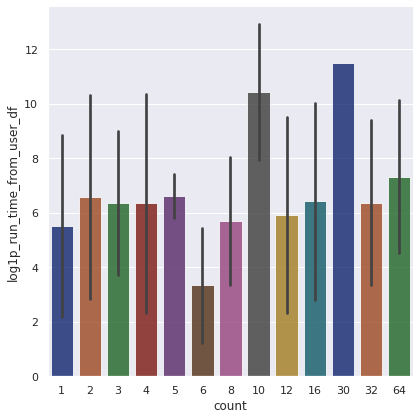

In [61]:
g = sns.catplot(
    data=gpu_user_join, kind="bar",
    x="count", y=target, 
    ci="sd", palette="dark", alpha=.8, height=6
)

Next we look at reuntimes that requested high memory.

In [62]:
avg_time_large = gpu_user_join[gpu_user_join['large_mem_req'] == 1][target].mean()
avg_time_small = gpu_user_join[gpu_user_join['large_mem_req'] == 0][target].mean()

print(f"The average runtime with a large requested memory is {round(np.exp(avg_time_large), 3)}.")
print(f"Whereas the average is {round(np.exp(avg_time_small), 3)} for small memory runtimes.")

The average runtime with a large requested memory is 543.302.
Whereas the average is 55.151 for small memory runtimes.


<AxesSubplot:xlabel='log1p_run_time_from_user_df', ylabel='large_mem_req'>

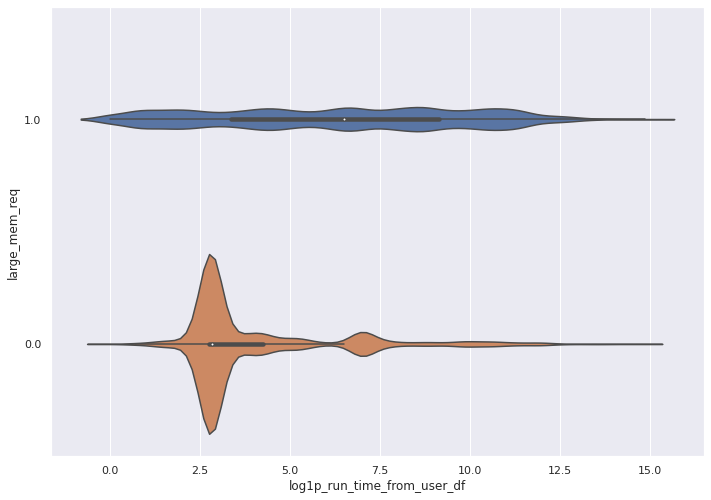

In [63]:
sns.violinplot(x=gpu_user_join[target], y=gpu_user_join["large_mem_req"].astype('str'))

In [64]:
reults_df= pd.DataFrame({'model': ['knn', 'svm', 'lgb'], 
                         'rmse': [knn_val_rmse, svm_val_rmse, lgb_val_rmse]})

Here we plot the rmse of the various models

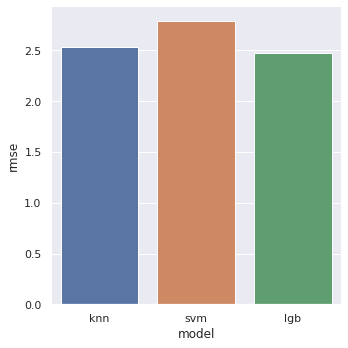

In [65]:
import seaborn as sns
sns.catplot(y='rmse', x='model', data=reults_df, kind='bar')

# Part 8. Conclusions <a id="8"></a>

Indeed, AI can be a very effective tool in predicting runtimes in a data center scenario. Over a 10-fold cross-validation of the data, a simple out-of-the-box AI model can obtain very good results (ie. R^2 ~ 0.98 on average).
Moreover, we have shown evidence that whether or not a runtime requests large memory resources beforehand is the best indicator of the resulting length of the runtime itself. It is likely that excessively large requests for resources are perhaps capped by a background system, however, the point still remains. 

This is the first time I set out to do a mini-project like this so any feedback to make it better is very welcomed. 
Thanks for reading; have a great day.


Refferences: 

[1] "The MIT Supercloud Dataset" https://arxiv.org/ftp/arxiv/papers/2108/2108.02037.pdf 

[2] Gelman, A. B., & Hill, J. (2009). Data analysis using regression and multilevel/hierarchical models. Cambridge University Press.